<a href="https://colab.research.google.com/github/Mandiparaut/Mandiparaut.github.io/blob/master/NOD_CNI_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# N.O.D — Community Nutrition Index (CNI) Analysis  

### RBC HubHacks 2025 | Virtusa x Digital Nova Scotia  

---

## Project Overview  
This notebook analyzes nutrition, economic, and accessibility data for Nova Scotia communities.  


In [ ]:
# Import required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Loading datasets
data = pd.read_excel("/content/NOD_NovaScotia.xlsx")

# Display the first few rows of the dataset
data.head(5)

,Region,Latitude,Longitude,VitaminA_Deficiency_%,Protein_Deficiency_%,Iron_Deficiency_%,Fruit_Veg_Consumption_%,Food_Insecurity_%,Obesity_Rate_%,Main_Crop,...,Crop_Diversity_Score,Median_Income_$,Low_Income_%,Unemployment_%,Access_to_Grocery_%,Food_Cost_Index,Raw_CNI,CNI_Score,v1,98.09
0,Halifax Central,44.65,-63.57,10,8,7,88,15,25,Vegetables,...,8,67000,14,6,94,95,115.24,90.000000,v2,115.24
1,Dartmouth,44.67,-63.57,13,10,9,82,17,26,Mixed Veg,...,7,64000,16,7,92,94,112.67,84.005831,NaN,NaN
2,Bedford,44.74,-63.67,12,9,8,84,18,25,Barley,...,8,65000,17,6,90,92,113.17,85.172012,NaN,NaN
3,Sackville,44.77,-63.68,14,11,10,80,20,28,Potatoes,...,7,63000,19,7,88,90,111.07,80.274052,NaN,NaN
4,Timberlea,44.65,-63.75,16,13,12,76,22,29,Corn,...,6,61000,21,8,86,88,109.07,75.609329,NaN,NaN


In [ ]:
# Drop the last two columns
data = data.iloc[:, :-2]

# Display the first few rows of the dataset
data.head()

,Region,Latitude,Longitude,VitaminA_Deficiency_%,Protein_Deficiency_%,Iron_Deficiency_%,Fruit_Veg_Consumption_%,Food_Insecurity_%,Obesity_Rate_%,Main_Crop,...,Farm_Count,Farmer_Income_$,Crop_Diversity_Score,Median_Income_$,Low_Income_%,Unemployment_%,Access_to_Grocery_%,Food_Cost_Index,Raw_CNI,CNI_Score
0,Halifax Central,44.65,-63.57,10,8,7,88,15,25,Vegetables,...,200,64000,8,67000,14,6,94,95,115.24,90.000000
1,Dartmouth,44.67,-63.57,13,10,9,82,17,26,Mixed Veg,...,180,61000,7,64000,16,7,92,94,112.67,84.005831
2,Bedford,44.74,-63.67,12,9,8,84,18,25,Barley,...,160,60000,8,65000,17,6,90,92,113.17,85.172012
3,Sackville,44.77,-63.68,14,11,10,80,20,28,Potatoes,...,150,58000,7,63000,19,7,88,90,111.07,80.274052
4,Timberlea,44.65,-63.75,16,13,12,76,22,29,Corn,...,140,56000,6,61000,21,8,86,88,109.07,75.609329


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Region                   120 non-null    object 
 1   Latitude                 120 non-null    float64
 2   Longitude                120 non-null    float64
 3   VitaminA_Deficiency_%    120 non-null    int64  
 4   Protein_Deficiency_%     120 non-null    int64  
 5   Iron_Deficiency_%        120 non-null    int64  
 6   Fruit_Veg_Consumption_%  120 non-null    int64  
 7   Food_Insecurity_%        120 non-null    int64  
 8   Obesity_Rate_%           120 non-null    int64  
 9   Main_Crop                120 non-null    object 
 10  Crop_Yield_tonnes        120 non-null    int64  
 11  Farm_Count               120 non-null    int64  
 12  Farmer_Income_$          120 non-null    int64  
 13  Crop_Diversity_Score     120 non-null    int64  
 14  Median_Income_$          1

In [ ]:
# Check for missing values in each column

data.isnull().sum()

,0
Region,0
Latitude,0
Longitude,0
VitaminA_Deficiency_%,0
Protein_Deficiency_%,0
Iron_Deficiency_%,0
Fruit_Veg_Consumption_%,0
Food_Insecurity_%,0
Obesity_Rate_%,0
Main_Crop,0


In [ ]:
# Display the shape of the dataset
data.shape

(120, 21)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.columns

Index(['Region', 'Latitude', 'Longitude', 'VitaminA_Deficiency_%',
       'Protein_Deficiency_%', 'Iron_Deficiency_%', 'Fruit_Veg_Consumption_%',
       'Food_Insecurity_%', 'Obesity_Rate_%', 'Main_Crop', 'Crop_Yield_tonnes',
       'Farm_Count', 'Farmer_Income_$', 'Crop_Diversity_Score',
       'Median_Income_$', 'Low_Income_%', 'Unemployment_%',
       'Access_to_Grocery_%', 'Food_Cost_Index', 'Raw_CNI', 'CNI_Score'],
      dtype='object')

In [ ]:
data.describe()

,Latitude,Longitude,VitaminA_Deficiency_%,Protein_Deficiency_%,Iron_Deficiency_%,Fruit_Veg_Consumption_%,Food_Insecurity_%,Obesity_Rate_%,Crop_Yield_tonnes,Farm_Count,Farmer_Income_$,Crop_Diversity_Score,Median_Income_$,Low_Income_%,Unemployment_%,Access_to_Grocery_%,Food_Cost_Index,Raw_CNI,CNI_Score
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,44.999583,-63.188750,19.783333,16.408333,13.041667,70.775000,25.583333,31.183333,797.750000,122.333333,53833.333333,5.800000,56366.666667,24.008333,8.691667,80.275000,85.375000,105.902667,68.221963
std,0.736212,1.817848,3.989868,3.565700,2.648595,6.197672,4.330046,2.497001,51.424457,22.416356,3616.798653,0.913024,3919.212177,3.758455,1.200811,5.960602,3.243772,3.685667,8.596308
min,43.840000,-65.350000,10.000000,8.000000,7.000000,58.000000,15.000000,25.000000,700.000000,85.000000,47000.000000,4.000000,48000.000000,14.000000,6.000000,68.000000,79.000000,98.090000,50.000000
25%,44.450000,-64.352500,17.000000,14.000000,11.000000,67.000000,22.750000,29.750000,760.000000,105.000000,52000.000000,5.000000,54000.000000,21.000000,8.000000,76.000000,83.000000,103.470000,62.548105
50%,44.910000,-63.940000,20.000000,17.000000,13.000000,70.000000,25.000000,31.000000,800.000000,120.000000,54000.000000,6.000000,56000.000000,24.000000,9.000000,80.000000,85.000000,105.945000,68.320700
75%,45.325000,-62.045000,23.000000,19.000000,15.000000,75.000000,28.250000,33.000000,830.000000,135.000000,56000.000000,6.000000,59000.000000,27.000000,9.000000,84.000000,87.000000,108.630000,74.583090
max,46.390000,-59.890000,28.000000,24.000000,20.000000,88.000000,34.000000,36.000000,950.000000,200.000000,64000.000000,8.000000,67000.000000,31.000000,12.000000,94.000000,95.000000,115.240000,90.000000


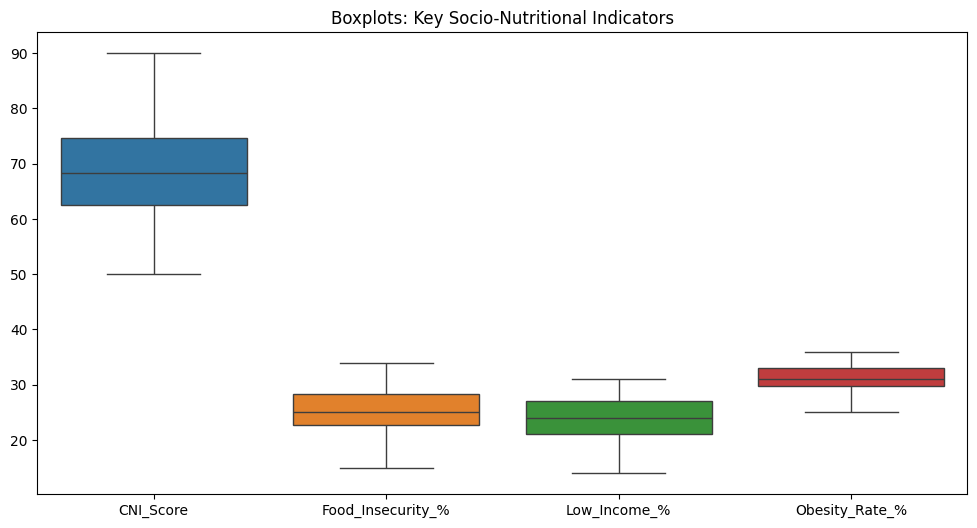

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data[['CNI_Score','Food_Insecurity_%','Low_Income_%','Obesity_Rate_%']])
plt.title("Boxplots: Key Socio-Nutritional Indicators")
plt.show()


In [ ]:
corr = data.corr(numeric_only=True)
corr


,Latitude,Longitude,VitaminA_Deficiency_%,Protein_Deficiency_%,Iron_Deficiency_%,Fruit_Veg_Consumption_%,Food_Insecurity_%,Obesity_Rate_%,Crop_Yield_tonnes,Farm_Count,Farmer_Income_$,Crop_Diversity_Score,Median_Income_$,Low_Income_%,Unemployment_%,Access_to_Grocery_%,Food_Cost_Index,Raw_CNI,CNI_Score
Latitude,1.000000,0.936567,0.020081,0.029900,-0.019858,-0.037444,0.029865,0.027012,0.050472,0.032190,0.022728,-0.061758,0.025100,0.036081,0.003466,-0.030939,-0.024355,-0.029044,-0.029044
Longitude,0.936567,1.000000,-0.008015,0.003317,-0.045983,-0.023656,0.024365,0.008724,0.071504,0.066588,0.026195,-0.056504,0.043010,0.022359,0.009186,-0.002157,0.004979,-0.010748,-0.010748
VitaminA_Deficiency_%,0.020081,-0.008015,1.000000,0.995654,0.976578,-0.986825,0.983114,0.976555,-0.986176,-0.953132,-0.979675,-0.904732,-0.971328,0.987517,0.915538,-0.979431,-0.957228,-0.994724,-0.994724
Protein_Deficiency_%,0.029900,0.003317,0.995654,1.000000,0.977854,-0.992467,0.981004,0.978758,-0.985308,-0.955598,-0.979253,-0.909108,-0.968715,0.988594,0.914788,-0.978366,-0.962208,-0.996083,-0.996083
Iron_Deficiency_%,-0.019858,-0.045983,0.976578,0.977854,1.000000,-0.971575,0.959207,0.965784,-0.966723,-0.933678,-0.967730,-0.889601,-0.945409,0.966536,0.915626,-0.950867,-0.923212,-0.977742,-0.977742
Fruit_Veg_Consumption_%,-0.037444,-0.023656,-0.986825,-0.992467,-0.971575,1.000000,-0.978313,-0.978527,0.984774,0.958592,0.982016,0.909744,0.968653,-0.986229,-0.919491,0.973691,0.967717,0.994893,0.994893
Food_Insecurity_%,0.029865,0.024365,0.983114,0.981004,0.959207,-0.978313,1.000000,0.982531,-0.974894,-0.931409,-0.982661,-0.914001,-0.980288,0.989041,0.941551,-0.983687,-0.950829,-0.990987,-0.990987
Obesity_Rate_%,0.027012,0.008724,0.976555,0.978758,0.965784,-0.978527,0.982531,1.000000,-0.969901,-0.930259,-0.973599,-0.920018,-0.971234,0.983898,0.938261,-0.970018,-0.949563,-0.986174,-0.986174
Crop_Yield_tonnes,0.050472,0.071504,-0.986176,-0.985308,-0.966723,0.984774,-0.974894,-0.969901,1.000000,0.971591,0.982016,0.895967,0.974789,-0.979472,-0.904043,0.978295,0.971333,0.987667,0.987667
Farm_Count,0.032190,0.066588,-0.953132,-0.955598,-0.933678,0.958592,-0.931409,-0.930259,0.971591,1.000000,0.953222,0.868803,0.927081,-0.947284,-0.844047,0.943574,0.970771,0.953494,0.953494


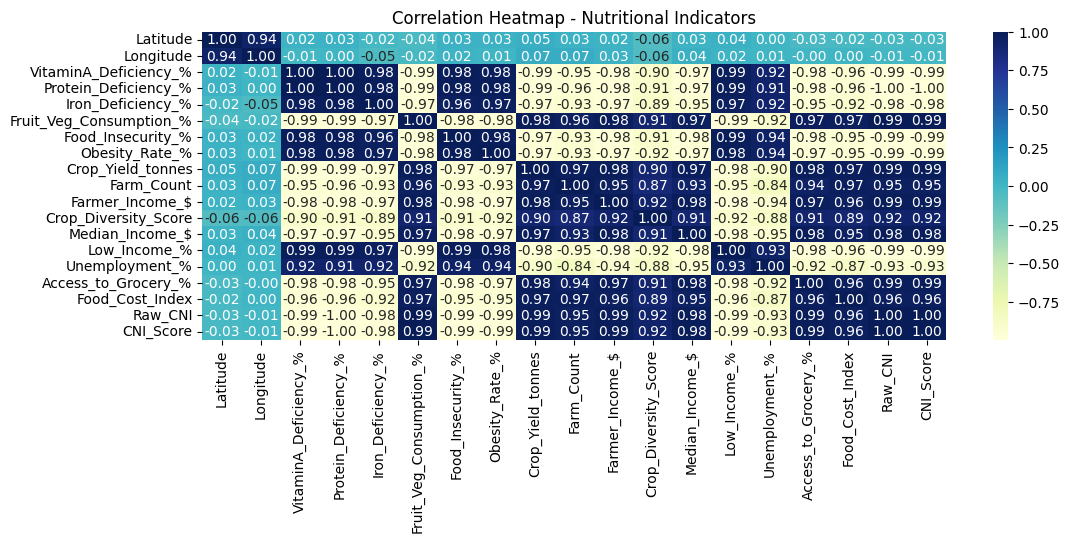

In [ ]:
plt.figure(figsize=(12,4))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Heatmap - Nutritional Indicators')
plt.show()


In [ ]:
import folium
from folium.plugins import HeatMap


# Create base map centered roughly on Nova Scotia
ns_center = [44.6820, -63.7443]
m = folium.Map(location=ns_center, zoom_start=7, tiles='CartoDB positron')

# Create heat data
heat_data = [[row['Latitude'], row['Longitude'], row['Food_Insecurity_%']] for index, row in data.iterrows()]

# Add heatmap layer
HeatMap(heat_data, radius=15, blur=20, max_zoom=12).add_to(m)

# Display the map directly inside Google Colab
m

This code creates an interactive heatmap of food insecurity levels across Nova Scotia. It first imports the Folium library, which is used for making maps, and sets a base map centered on Nova Scotia using its latitude and longitude. The heat_data list gathers each region’s coordinates and food insecurity percentage from the dataset. Then, the HeatMap function plots these points on the map, where areas with higher food insecurity appear in warmer colors (red or orange) and lower levels in cooler colors (green or yellow). Finally, displaying m in Colab shows the interactive map, allowing users to visually explore which regions face the greatest nutrition challenges.


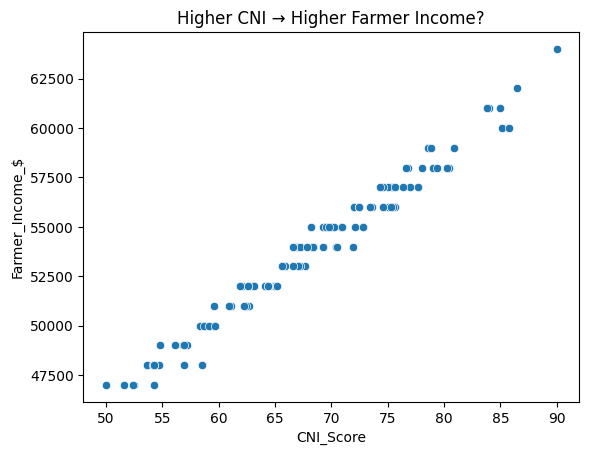

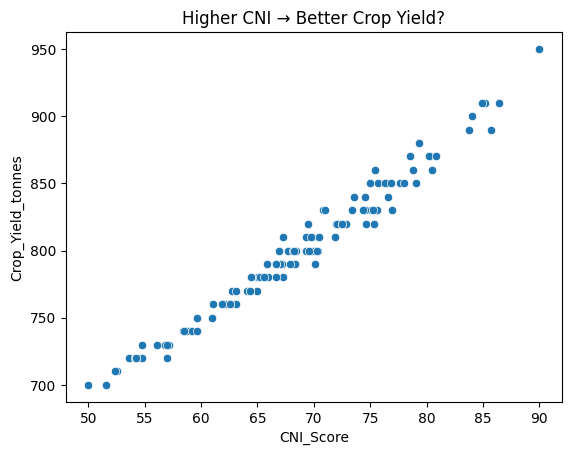

,CNI_Score,Farmer_Income_$,Crop_Yield_tonnes,Food_Insecurity_%,Low_Income_%
CNI_Score,1.000000,0.987440,0.987667,-0.990987,-0.994295
Farmer_Income_$,0.987440,1.000000,0.982016,-0.982661,-0.984668
Crop_Yield_tonnes,0.987667,0.982016,1.000000,-0.974894,-0.979472
Food_Insecurity_%,-0.990987,-0.982661,-0.974894,1.000000,0.989041
Low_Income_%,-0.994295,-0.984668,-0.979472,0.989041,1.000000


In [ ]:
# CNI vs Farmer Income
sns.scatterplot(x='CNI_Score', y='Farmer_Income_$', data=data)
plt.title('Higher CNI → Higher Farmer Income?')
plt.show()

# CNI vs Crop Yield
sns.scatterplot(x='CNI_Score', y='Crop_Yield_tonnes', data=data)
plt.title('Higher CNI → Better Crop Yield?')
plt.show()

# Correlation table
data[['CNI_Score','Farmer_Income_$','Crop_Yield_tonnes','Food_Insecurity_%','Low_Income_%']].corr()


 Relationship Analysis

I analyzed how the CNI Score relates to key factors like Farmer Income, Crop Yield, and Food Insecurity. Scatter plots and correlations showed that regions with higher CNI generally have higher income and yield, while those with lower CNI face more food insecurity. This suggests that improving nutrition and crop diversity can boost both productivity and economic well-being.

K-Means Clustering —  We’ll use it to group regions that have similar nutrition and deficiency patterns based on your dataset columns (like deficiencies, food insecurity, obesity, etc.).

What Is K-Means?

K-Means is a simple machine-learning method that groups similar data points together.
Here, each region is one data point, and we group them based on how similar their nutrition and deficiency numbers are.

In [ ]:
# Select relevant features
features = ['VitaminA_Deficiency_%', 'Protein_Deficiency_%', 'Iron_Deficiency_%',
            'Fruit_Veg_Consumption_%', 'Food_Insecurity_%', 'Obesity_Rate_%',
            'Crop_Diversity_Score', 'CNI_Score']

X = data[features]

# Standardize the data (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Above
Step 1 — Pick features (diet/deficiency profile)
Why: Choose numeric columns that describe nutrition/deficiency and diversity. Exclude text columns like Region, Main_Crop.

Step 2 — Scale features (very important)
Why: K-Means uses distance; scaling puts all features on comparable footing so one feature doesn’t dominate.

Different columns have different scales (e.g., some in %, some in dollars).
Standardizing makes all values comparable — it turns them into numbers with a mean of 0 and equal range.
This is very important because K-Means measures distance between points.

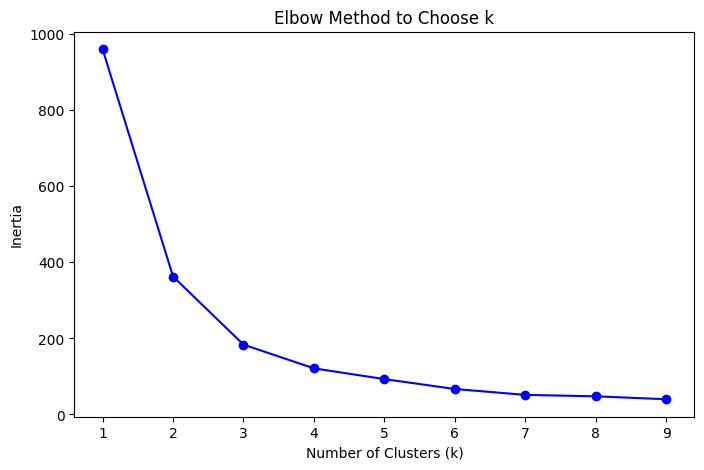

In [ ]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Choose k')
plt.show()


We test several possible numbers of clusters (1 to 9).
The Elbow Method plot helps us see where adding more clusters stops improving results much — the “bend” of the curve is the best choice for k.

Here, we actually create the clusters (3 groups in this example).
Each region is automatically labeled as Cluster 0, Cluster 1, or Cluster 2 depending on its pattern of values.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# View cluster centers
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
print("Cluster Centers:")
print(centers)


Cluster Centers:
   VitaminA_Deficiency_%  Protein_Deficiency_%  Iron_Deficiency_%  \
0              24.170732             20.243902          15.902439   
1              14.217391             11.304348           9.434783   
2              18.857143             15.696429          12.428571   

   Fruit_Veg_Consumption_%  Food_Insecurity_%  Obesity_Rate_%  \
0                64.365854          30.365854       33.878049   
1                79.913043          19.652174       27.652174   
2                71.714286          24.517857       30.660714   

   Crop_Diversity_Score  CNI_Score  
0              4.829268  58.890279  
1              7.130435  80.455571  
2              5.964286  70.029571  


These are the average values of each group.
They help you see what makes each cluster unique (for example, Cluster 0 might have high CNI and low food insecurity).

Step 4 — Fit K-Means and attach cluster labels

(Assume k = 3; change if your plots suggest otherwise.)
Why: This assigns each region to the nearest cluster center based on its nutrition/deficiency profile.


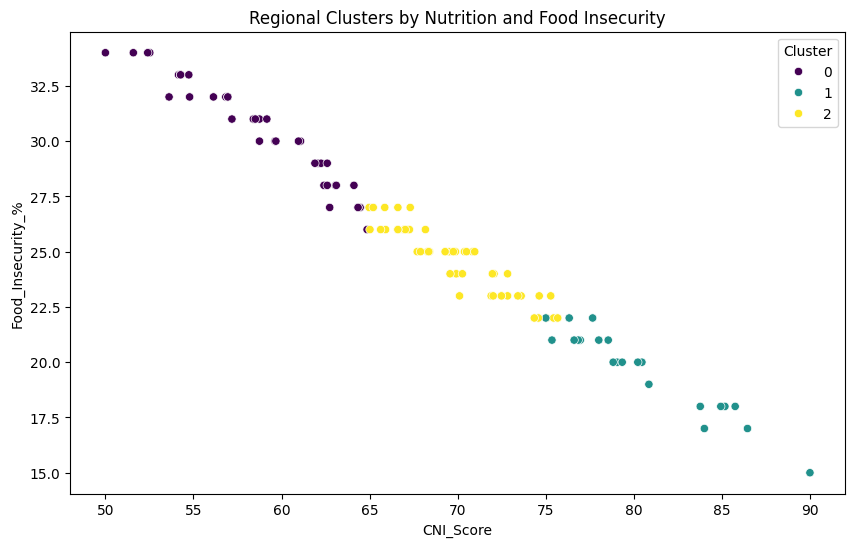

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='CNI_Score', y='Food_Insecurity_%', hue='Cluster', data=data, palette='viridis')
plt.title('Regional Clusters by Nutrition and Food Insecurity')
plt.show()


this draws a scatter plot showing how clusters are spread out.
You can visually see which regions are doing well and which are struggling.

Each cluster can be plotted on a Folium map with different colors to show where the similar regions are located in Nova Scotia.

In [ ]:
import folium

m = folium.Map(location=[44.6820, -63.7443], zoom_start=7, tiles='CartoDB positron')

colors = ['green', 'orange', 'red']

for i, row in data.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        color=colors[row['Cluster']],
        fill=True,
        fill_color=colors[row['Cluster']],
        fill_opacity=0.7,
        popup=f"{row['Region']} - Cluster {row['Cluster']}"
    ).add_to(m)

m


I applied K-Means clustering to group regions in Nova Scotia based on their nutritional and deficiency indicators. Using features such as vitamin, protein, and iron deficiency, food insecurity, obesity, crop diversity, and CNI Score, the model grouped regions into three clusters with similar patterns. The results show clear distinctions between high-nutrition regions, moderate regions, and nutritionally at-risk areas, helping identify where targeted health and agricultural support is most needed.

In this project, I used it to find patterns among Nova Scotia regions using columns such as vitamin, protein, and iron deficiency, food insecurity, obesity rate, crop diversity score, and the CNI Score. First, I selected only these numerical columns and standardized them so that all values were on the same scale. This step is important because K-Means compares distances between points, and large numbers could otherwise dominate the results.

Next, I used the Elbow Method to decide how many clusters (groups) made sense. After choosing three clusters, the model automatically assigned each region to one of them — for example, Cluster 0, Cluster 1, or Cluster 2 — based on how similar their values were. I then visualized these clusters on a scatter plot and map to see how regions are grouped. The results helped identify patterns such as regions with good nutrition and high CNI, moderate conditions, and areas facing nutritional challenges.

The map displays color-coded clusters of Nova Scotia regions based on their nutritional and deficiency data.

Each color represents a different group of regions that share similar characteristics identified by the K-Means model.

For example,
 green areas may indicate regions with better nutrition and higher CNI scores,
orange areas show moderate conditions,
 and red areas highlight regions facing higher nutritional challenges or food insecurity.


This visual makes it easy to see where nutrition-related issues are concentrated and helps guide policymakers or organizations to focus support in the most affected areas.

## Why remove the green cluster?

If green represents regions that are already doing well (for example:
high CNI,
low deficiencies,
good nutrition),
then focusing only on red (at-risk) and orange (moderate) regions makes total sense.

It helps us map clearly show where help or attention is needed most — and avoids cluttering the map with already-healthy areas.



In [ ]:
m = folium.Map(location=[44.6820, -63.7443], zoom_start=7, tiles='CartoDB positron')

colors = ['green', 'orange', 'red']

# Filter out the green cluster (Cluster 0)
filtered_data = data[data['Cluster'] != 0]  # change 0 if green is another number

for i, row in filtered_data.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        color=colors[row['Cluster']],
        fill=True,
        fill_color=colors[row['Cluster']],
        fill_opacity=0.7,
        popup=f"{row['Region']} - Cluster {row['Cluster']}"
    ).add_to(m)

m


Filtered Cluster Visualization

To focus on regions that need improvement, I removed the green cluster, which represented areas with good nutrition and high CNI scores. The map now highlights only the orange and red clusters, showing moderate and nutritionally at-risk regions. This helps clearly visualize where targeted interventions and support are most needed in Nova Scotia.

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import folium

# Use only at-risk regions
filtered_data = data[data['Cluster'].isin([1, 2])][['Region','Latitude','Longitude']].reset_index(drop=True)

# Try different numbers of food banks (k)
k = 5  # you can test 3, 5, 7 depending on budget
kmeans = KMeans(n_clusters=k, random_state=42)
filtered_data['FoodBank_Group'] = kmeans.fit_predict(filtered_data[['Latitude','Longitude']])

# Get cluster centers (best food bank locations)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['Latitude','Longitude'])
centers


,Latitude,Longitude
0,46.152500,-60.184500
1,44.989091,-64.095909
2,44.720500,-63.606500
3,44.042857,-64.752143
4,44.223333,-65.130000


In [ ]:
m = folium.Map(location=[44.6820, -63.7443], zoom_start=7, tiles='CartoDB positron')

# Add all low-CNI regions
for _, row in filtered_data.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"{row['Region']} (Group {row['FoodBank_Group']})"
    ).add_to(m)

# Add proposed food bank locations
for i, row in centers.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Food Bank Center {i+1}",
        icon=folium.Icon(color='blue', icon='cutlery', prefix='fa')
    ).add_to(m)

m


I used the K-Means algorithm to find the most suitable locations for food banks based on the latitude and longitude of low-CNI regions. Instead of calculating distances manually, the algorithm automatically grouped nearby areas together and selected a central point for each group. Each central point represents the best location for a food bank that can serve all surrounding regions efficiently. By adjusting the number of groups (for example, 5 or 6), I can control how many food banks are needed — balancing cost and coverage across Nova Scotia.

Orange and red dots = all your low-CNI regions

Blue markers = the optimal central food-bank locations for each cluster

## Machine Learning Regression

Farmer_Income_$ → predicts income based on nutrition indicators,
or

Crop_Yield_tonnes → predicts yield based on nutrition and economic factors.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select features (X) and target (y)
X = data[['CNI_Score', 'Crop_Diversity_Score', 'Food_Insecurity_%', 'Low_Income_%', 'Obesity_Rate_%']]
y = data['Farmer_Income_$']

##here We pick the independent variables (features)
## that affect income, and the dependent variable (target) we want to predict.


In [ ]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# predict and evulate

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)



Mean Absolute Error: 450.43115265473716
Root Mean Squared Error: 538.2750106272107
R² Score: 0.9807174774639102


MAE and RMSE → show average prediction error (lower = better).

R² Score → accuracy measure (closer to 1 = better prediction).

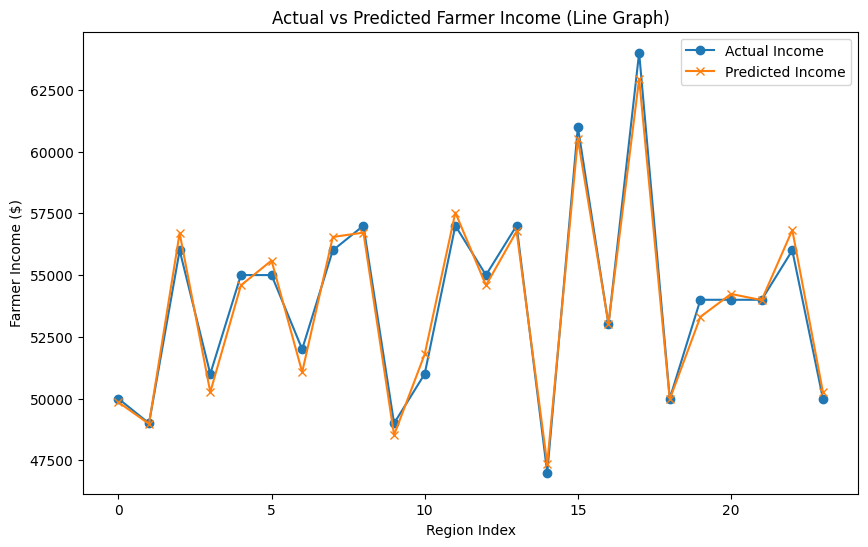

In [ ]:
#Visualize Predictions

plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual Income', marker='o')
plt.plot(y_pred, label='Predicted Income', marker='x')
plt.title('Actual vs Predicted Farmer Income (Line Graph)')
plt.xlabel('Region Index')
plt.ylabel('Farmer Income ($)')
plt.legend()
plt.show()


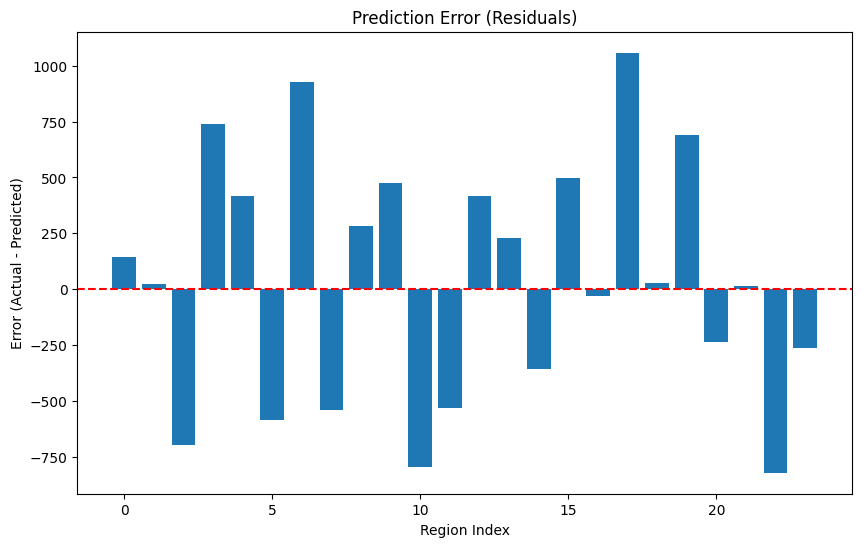

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.bar(range(len(residuals)), residuals)
plt.title('Prediction Error (Residuals)')
plt.xlabel('Region Index')
plt.ylabel('Error (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--')
plt.show()


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

importance


,Feature,Coefficient
0,CNI_Score,282.190852
1,Crop_Diversity_Score,240.832215
4,Obesity_Rate_%,168.903324
2,Food_Insecurity_%,-157.743826
3,Low_Income_%,-181.504720


Positive coefficients → increase income
Negative coefficients → decrease income

## Holt-Winters Exponential Smoothing Forecasting Concept

The Holt-Winters Exponential Smoothing method is a time-series forecasting technique used to predict future values based on past trends and seasonal patterns.

It works by applying smoothing factors to three components — level, trend, and seasonality — to give more weight to recent observations while still considering older data.

Although our current dataset does not contain enough time-based data to perform a full forecasting model, this method could be applied in the future as more information becomes available. For example, if we collect monthly or yearly data on crop yields, food insecurity rates, or CNI scores, Holt-Winters could be used to forecast future nutritional and agricultural trends, helping decision-makers plan resources and food-bank operations more effectively.


In [ ]:
"""
Holt-Winters Exponential Smoothing Forecasting Script

This script takes:
1. A list of 24 values (monthly data over 2 years)
2. Number of months to forecast ahead

Returns: A single projected value for that future month
"""

def holt_winters_forecast(data, months_ahead, alpha=0.2, beta=0.1, gamma=0.1):
    """
    Holt-Winters multiplicative seasonal forecasting method.

    Parameters:
    -----------
    data : list
        List of 24 monthly values (2 years of data)
    months_ahead : int
        Number of months to forecast into the future
    alpha : float
        Smoothing parameter for level (0 < alpha < 1)
    beta : float
        Smoothing parameter for trend (0 < beta < 1)
    gamma : float
        Smoothing parameter for seasonality (0 < gamma < 1)

    Returns:
    --------
    float
        The forecasted value for the specified month
    """
    if len(data) != 24:
        raise ValueError("Input data must contain exactly 24 values (2 years of monthly data)")

    if months_ahead < 1:
        raise ValueError("months_ahead must be at least 1")

    seasonal_period = 12  # Monthly seasonality

    # Initialize components
    # Level: average of first year
    level = sum(data[:12]) / 12

    # Trend: difference between average of year 2 and year 1
    trend = (sum(data[12:24]) / 12 - sum(data[:12]) / 12) / 12

    # Seasonal indices: average ratio for each month
    seasonal = []
    for i in range(seasonal_period):
        seasonal.append((data[i] + data[i + 12]) / (2 * level))

    # Holt-Winters smoothing iterations
    for i in range(len(data)):
        old_level = level

        # Update level
        level = alpha * (data[i] / seasonal[i % seasonal_period]) + (1 - alpha) * (old_level + trend)

        # Update trend
        trend = beta * (level - old_level) + (1 - beta) * trend

        # Update seasonal component
        seasonal[i % seasonal_period] = gamma * (data[i] / level) + (1 - gamma) * seasonal[i % seasonal_period]

    # Forecast
    forecast = (level + months_ahead * trend) * seasonal[(len(data) + months_ahead - 1) % seasonal_period]

    return forecast


def main():
    """
    Example usage of the Holt-Winters forecast function
    """
    # Example: 24 months of sales data
    monthly_data = [
        100, 120, 135, 148, 155, 160, 162, 158, 152, 145, 130, 115,  # Year 1
        105, 125, 140, 153, 162, 168, 170, 165, 158, 150, 135, 120   # Year 2
    ]

    # Forecast 3 months ahead
    months_to_forecast = 3

    result = holt_winters_forecast(monthly_data, months_to_forecast)

    print(f"Historical data (24 months): {monthly_data}")
    print(f"Forecast for month {months_to_forecast} ahead: {result:.2f}")

    # Additional examples
    print("\n--- Additional Forecasts ---")
    for months in [1, 6, 12]:
        forecast = holt_winters_forecast(monthly_data, months)
        print(f"Forecast for month {months:2d} ahead: {forecast:.2f}")


if __name__ == "__main__":
    main()


Historical data (24 months): [100, 120, 135, 148, 155, 160, 162, 158, 152, 145, 130, 115, 105, 125, 140, 153, 162, 168, 170, 165, 158, 150, 135, 120]
Forecast for month 3 ahead: 142.06

--- Additional Forecasts ---
Forecast for month  1 ahead: 105.60
Forecast for month  6 ahead: 170.28
Forecast for month 12 ahead: 123.38


In [ ]:
crop_group = data.groupby("Main_Crop")[["VitaminA_Deficiency_%", "Protein_Deficiency_%", "Iron_Deficiency_%"]].mean()
crop_group


,VitaminA_Deficiency_%,Protein_Deficiency_%,Iron_Deficiency_%
Main_Crop,,,
Barley,20.083333,16.625000,13.083333
Carrots,21.600000,18.200000,14.200000
Corn,20.250000,16.833333,13.375000
Mixed Veg,19.714286,16.428571,13.095238
Potatoes,19.736842,16.210526,13.105263
Vegetables,13.625000,10.750000,9.250000
Wheat,20.857143,17.500000,13.571429


In [ ]:
crop_group.sort_values(by="VitaminA_Deficiency_%")


,VitaminA_Deficiency_%,Protein_Deficiency_%,Iron_Deficiency_%
Main_Crop,,,
Vegetables,13.625000,10.750000,9.250000
Mixed Veg,19.714286,16.428571,13.095238
Potatoes,19.736842,16.210526,13.105263
Barley,20.083333,16.625000,13.083333
Corn,20.250000,16.833333,13.375000
Wheat,20.857143,17.500000,13.571429
Carrots,21.600000,18.200000,14.200000


Text(0.5, 1.0, 'Average Nutrient Deficiency by Main Crop')

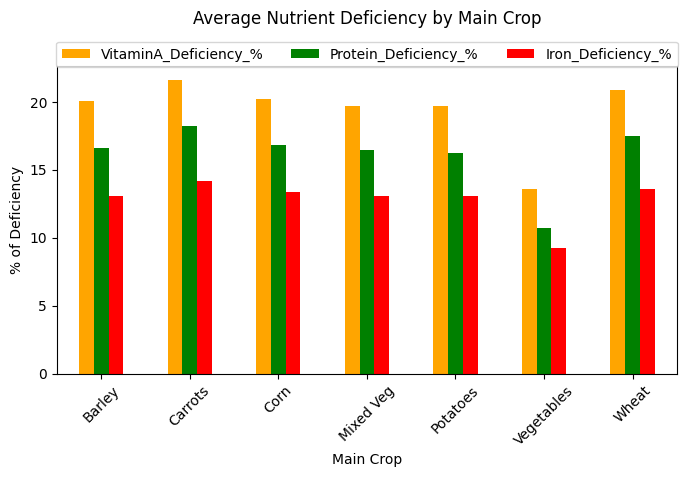

In [ ]:
crop_group.plot(kind='bar', figsize=(8,4), color=['orange','green','red'])
plt.title("Average Nutrient Deficiency by Main Crop")
plt.ylabel("% of Deficiency")
plt.xlabel("Main Crop")
plt.xticks(rotation=45)

# Move legend to top
plt.legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=3)

plt.title("Average Nutrient Deficiency by Main Crop", pad=30)


In this step, we visualized how different crops relate to nutrient deficiencies by creating a grouped bar chart showing the average percentages of Vitamin A, Protein, and Iron deficiencies for each main crop (e.g., Barley, Carrots, Corn, Potatoes, Vegetables, and Wheat).

Using Matplotlib and Pandas, we grouped the data by crop type and plotted three colored bars for each crop — orange for Vitamin A, green for Protein, and red for Iron — to compare how each crop performs nutritionally. We then adjusted the legend’s position to appear clearly above the chart without overlapping the title or bars, ensuring the visualization was clean and easy to interpret.

It shows the average percentage of Vitamin A, Protein, and Iron deficiencies for each crop — for example, Barley, Carrots, Corn, Potatoes, Vegetables, and Wheat. Each color represents one type of deficiency (orange for Vitamin A, green for Protein, red for Iron). This helps us clearly see which crops are linked to higher or lower nutrient deficiency levels.

# Efficiency

How well a crop supports good nutrition while maintaining good yield and income.

In [ ]:
# Create nutrient efficiency columns

# Efficiency = 100 - Deficiency
data['VitaminA_Efficiency'] = 100 - data['VitaminA_Deficiency_%']
data['Protein_Efficiency']  = 100 - data['Protein_Deficiency_%']
data['Iron_Efficiency']     = 100 - data['Iron_Deficiency_%']

In [ ]:
# Group by Main Crop and calculate mean efficiency
efficiency_group = data.groupby('Main_Crop')[['VitaminA_Efficiency', 'Protein_Efficiency', 'Iron_Efficiency']].mean()

#sort crops by overall Vitamin A efficiency (you can change to Protein/Iron)
efficiency_group = efficiency_group.sort_values(by='VitaminA_Efficiency', ascending=False)


<Figure size 1000x500 with 0 Axes>

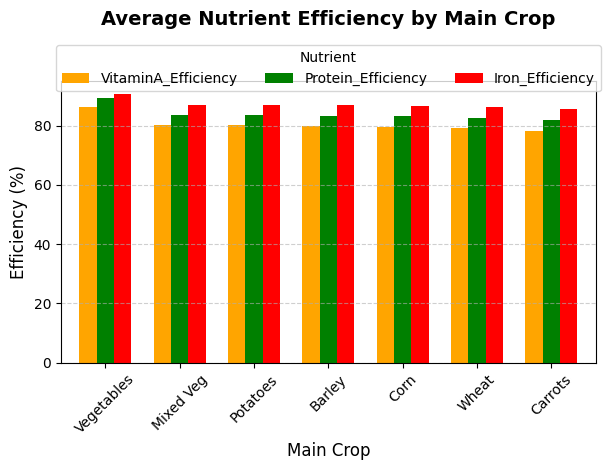

,VitaminA_Efficiency,Protein_Efficiency,Iron_Efficiency
Main_Crop,,,
Vegetables,86.0,89.0,91.0
Mixed Veg,80.0,84.0,87.0
Potatoes,80.0,84.0,87.0
Barley,80.0,83.0,87.0
Corn,80.0,83.0,87.0
Wheat,79.0,82.0,86.0
Carrots,78.0,82.0,86.0


In [ ]:

# Create a grouped bar chart
plt.figure(figsize=(10,5))
ax = efficiency_group.plot(kind='bar', color=['orange', 'green', 'red'], width=0.7)

# Format the chart
plt.title('Average Nutrient Efficiency by Main Crop', fontsize=14, weight='bold', pad=40)
plt.ylabel('Efficiency (%)', fontsize=12)
plt.xlabel('Main Crop', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Move legend to the top
plt.legend(title='Nutrient', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.tight_layout()
plt.show()

# (Optional) Display data table for reference ---
efficiency_group.round(0)


<Figure size 1000x500 with 0 Axes>

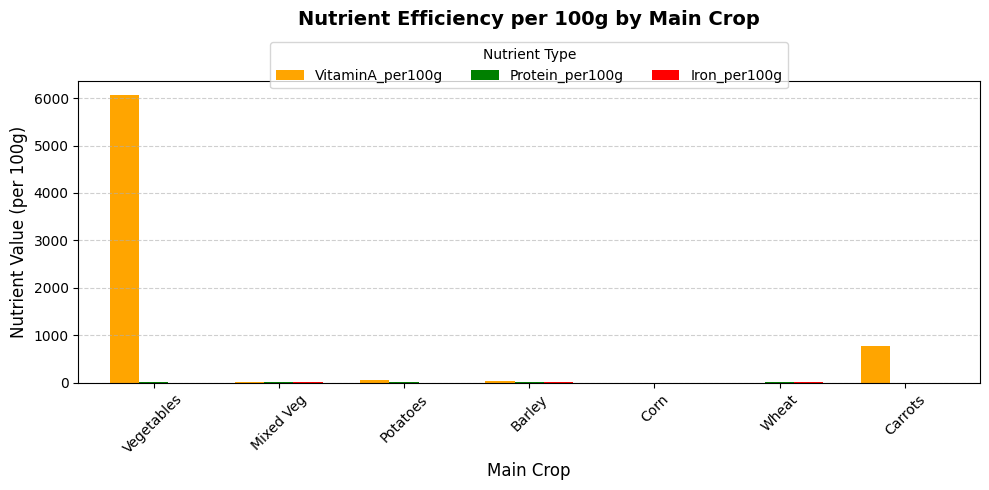

In [ ]:
# Create dataset (per 100 grams
data_eff = {
    'Main_Crop': ['Vegetables', 'Mixed Veg', 'Potatoes', 'Barley', 'Corn', 'Wheat', 'Carrots'],
    'VitaminA_per100g': [6067, 6, 64, 24, 1, 0, 762],     # μg of Vitamin A
    'Protein_per100g': [2.3, 8.74, 3.89, 2.2, 0.84, 10.7, 0.87],  # g of Protein
    'Iron_per100g': [0.83, 4.88, 0.75, 1.28, 0.49, 3.6, 0.12]     # mg of Iron
}

df_eff = pd.DataFrame(data_eff)

# Plot grouped bar chart
plt.figure(figsize=(10,5))
df_eff.set_index('Main_Crop')[['VitaminA_per100g', 'Protein_per100g', 'Iron_per100g']].plot(
    kind='bar',
    color=['orange', 'green', 'red'],
    width=0.7,
    figsize=(10,5)
)

# Format chart
plt.title('Nutrient Efficiency per 100g by Main Crop', fontsize=14, weight='bold', pad=40)
plt.ylabel('Nutrient Value (per 100g)', fontsize=12)
plt.xlabel('Main Crop', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(
    title='Nutrient Type',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3
)

plt.tight_layout()
plt.show()


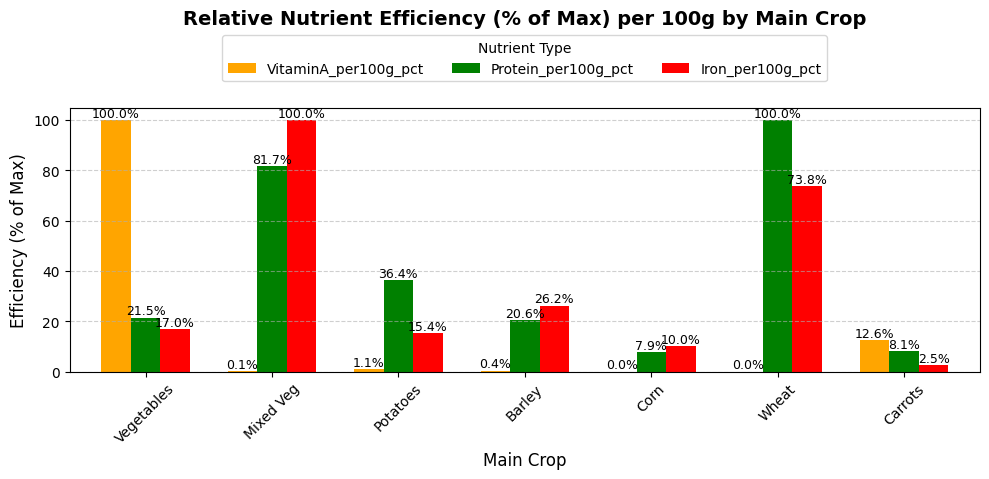

In [ ]:
# --- Step 1: Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 2: Create dataset (per 100 grams) ---
data_eff = {
    'Main_Crop': ['Vegetables', 'Mixed Veg', 'Potatoes', 'Barley', 'Corn', 'Wheat', 'Carrots'],
    'VitaminA_per100g': [6067, 6, 64, 24, 1, 0, 762],
    'Protein_per100g': [2.3, 8.74, 3.89, 2.2, 0.84, 10.7, 0.87],
    'Iron_per100g': [0.83, 4.88, 0.75, 1.28, 0.49, 3.6, 0.12]
}

df_eff = pd.DataFrame(data_eff)

# --- Step 3: Convert each nutrient to percentage of its maximum value ---
for col in ['VitaminA_per100g', 'Protein_per100g', 'Iron_per100g']:
    df_eff[col + '_pct'] = (df_eff[col] / df_eff[col].max()) * 100

# --- Step 4: Plot grouped bar chart ---
fig, ax = plt.subplots(figsize=(10,5))
bars = df_eff.set_index('Main_Crop')[['VitaminA_per100g_pct', 'Protein_per100g_pct', 'Iron_per100g_pct']].plot(
    kind='bar',
    color=['orange', 'green', 'red'],
    width=0.7,
    ax=ax
)

# --- Step 5: Add labels ---
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

# --- Step 6: Format chart ---
plt.title('Relative Nutrient Efficiency (% of Max) per 100g by Main Crop', fontsize=14, weight='bold', pad=60)
plt.ylabel('Efficiency (% of Max)', fontsize=12)
plt.xlabel('Main Crop', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(
    title='Nutrient Type',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.30),
    ncol=3
)
plt.tight_layout()
plt.show()
